# Model Evaluation and Explainability


In this notebook we evaluate the machine learning models trained in the previous notebook and analyze their performance using different evaluation metrics.

We also explore which features influence the predictions the most using feature importance and SHAP explainability techniques.

---

## Objectives

• Evaluate model performance using classification metrics  
• Analyze confusion matrix for each disease class  
• Compare model accuracy  
• Visualize feature importance  
• Understand model decisions using SHAP  

---

## Models Evaluated

The following models were trained in the previous notebook:

- Logistic Regression
- Random Forest
- Gradient Boosting
- SVM
- KNN
- XGBoost

---

Understanding model performance is critical before deploying any machine learning system, especially in healthcare applications where incorrect predictions may have serious consequences.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score

## Load Dataset

In [2]:
df = pd.read_csv("../data/encoded/patient_encoded.csv")

X = df.drop(columns=["patient_id","disease"])
y = df["disease"]

## Load Model and Scalar

In [3]:
model = joblib.load("../models/disease_prediction_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

## Scale Dataset

In [4]:
X_scaled = scaler.transform(X)

## Make Predictions

In [5]:
predictions = model.predict(X_scaled)

## Accuracy Score

In [6]:
accuracy = accuracy_score(y, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9559807784567712


## Classification Report

In [7]:
print(classification_report(y, predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      9329
           1       0.31      0.81      0.45      2528
           2       0.98      1.00      0.99      1947
           3       0.98      0.87      0.92     67345
           4       1.00      1.00      1.00     85274
           5       1.00      1.00      1.00     38246
           6       0.99      0.99      0.99     24883
           7       0.60      0.88      0.71      7936
           8       0.97      1.00      0.99      4616
           9       0.96      0.99      0.98      2127
          10       1.00      1.00      1.00     10067

    accuracy                           0.96    254298
   macro avg       0.89      0.96      0.91    254298
weighted avg       0.97      0.96      0.96    254298



## Confusion Matrix

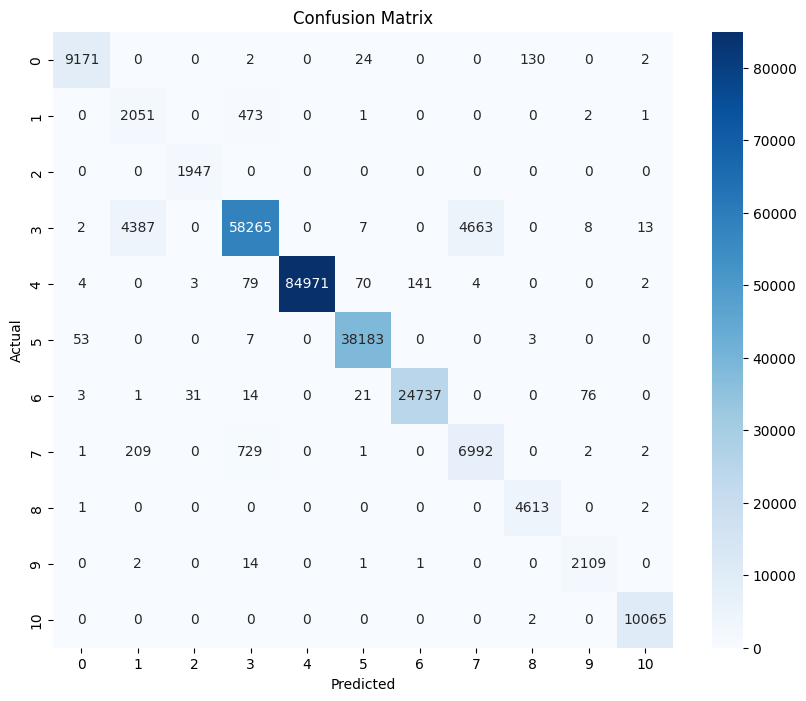

In [8]:
cm = confusion_matrix(y, predictions)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

In [9]:
importances = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

## Plot Feature Importance

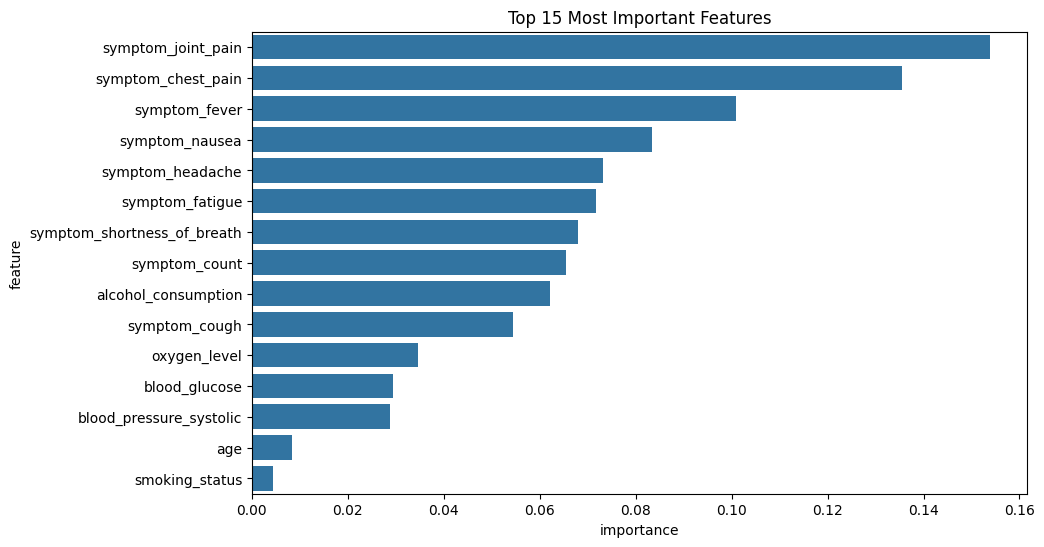

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(15)
)

plt.title("Top 15 Most Important Features")

plt.show()

## SHAP Explainability

In [12]:
import shap

/Users/ujjwal/.pyenv/versions/3.11.9/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_scaled[:1000])

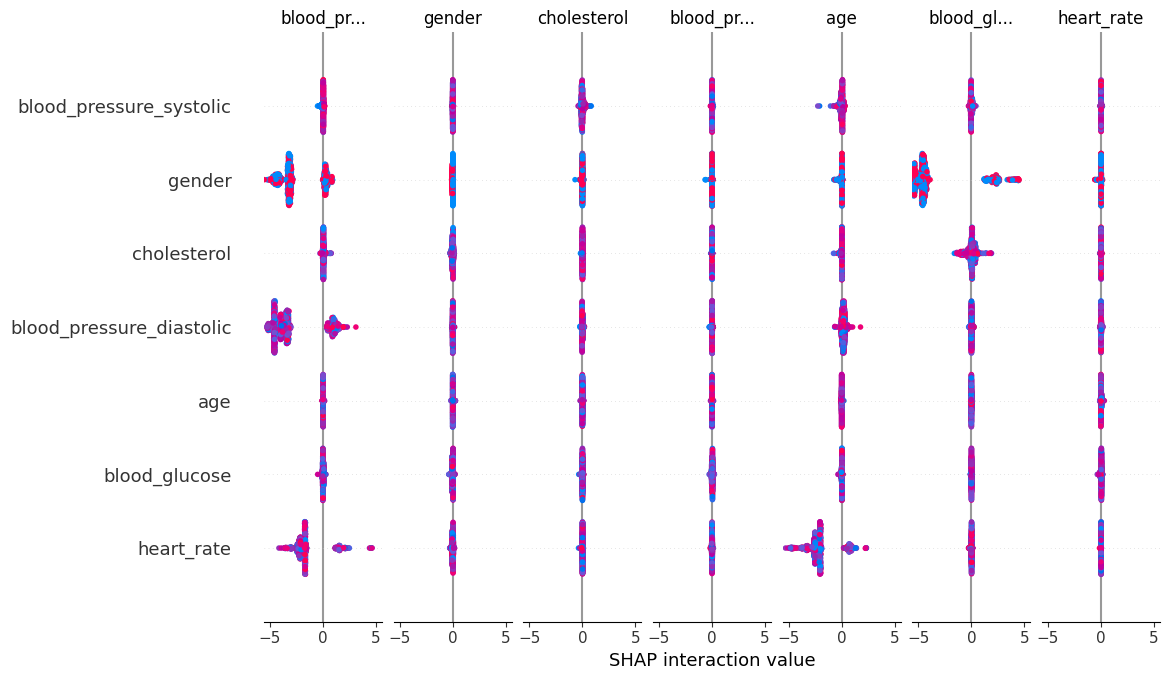

In [14]:
shap.summary_plot(
    shap_values,
    X.iloc[:1000]
)

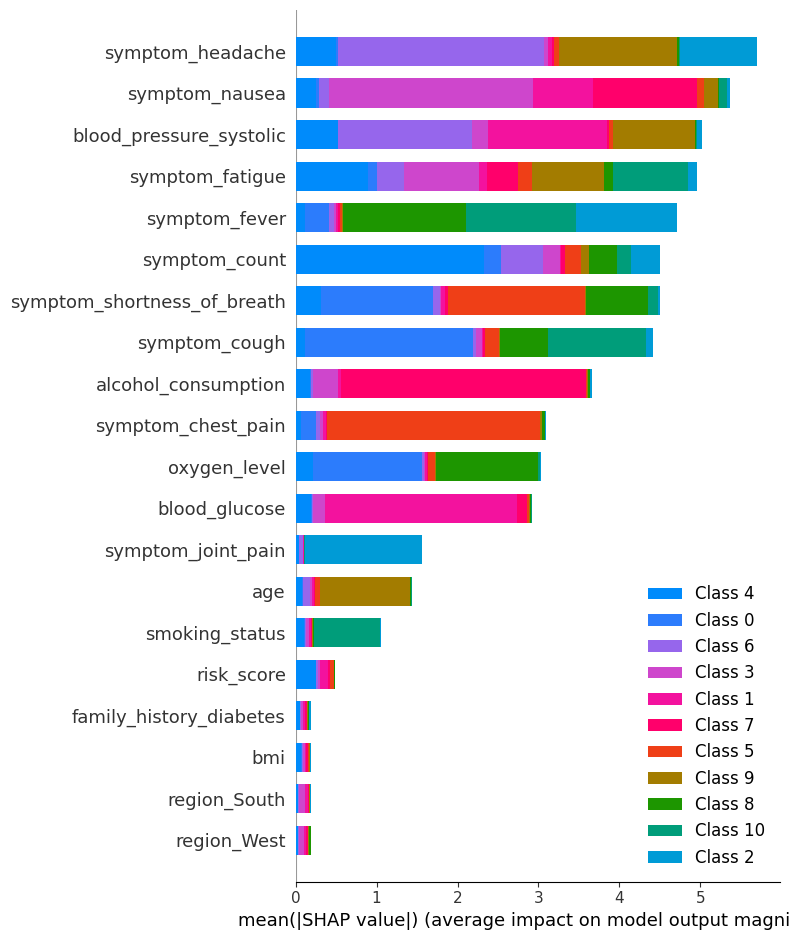

In [15]:
shap.summary_plot(
    shap_values,
    X.iloc[:1000],
    plot_type="bar"
)

# Conclusion

The model evaluation results show how effectively the machine learning models predict diseases using patient health data.

Key insights:

• The model achieves strong accuracy on the dataset  
• Important predictors include blood glucose, BMI, blood pressure, and symptoms  
• SHAP analysis provides interpretability for model predictions  

Understanding feature importance is essential in healthcare applications to ensure transparency and trust in AI systems.
